# **GEOL415 Lab 3**

Welcome to lab 3. This week will be a bit more free-form. 

**RECAP.** Last week, you:
- gained more experience with terminal commands.
- downloaded and properly imported tabular ice core data.
- analyzed said dataset.

**PREVIEW.** This week, you will:
- Look through a curated list of datasets provided to you by us.
- Select one you find interesting for your course project pitch next week.

As a reminder, this project will be:

**"...a data analysis report (5 pages single spaced, 0.5 inch margins, 12pt Arial font, at least 5 figures) and presentation on an earth and environmental science research topic. A grading rubric will be provided for the final project. The assignment is scaffolded throughout the semester with
intermediate due dates.'**

## **Select a dataset from the following options**
I will go through a couple of these with the class. Feel free to follow along or explore these on your own. 

# **Air Quality**

1. [EPA AQS pre-generated files](https://aqs.epa.gov/aqsweb/airdata/download_files.html) : hourly/daily pollutant concentrations from thousands of US monitors, by year and pollutant.

2. [OpenAQ](openaq.org) : global ground-station air quality data, API plus bulk archives. 

# **Weather/Climate**

1. [NOAA GHCN-Daily](https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00861): daily temperature, precipitation, snowfall from tens of thousands of stations worldwide.

2. [Berkeley Earth land temperature data](https://berkeleyearth.org/data/): cleaned, gridded and station-level temperature records.

# **Hydrology**
1. [USGS NWIS](https://waterdata.usgs.gov/): streamflow, gauge height, water quality from thousands of US gauges.

2. [CAMELS](https://ral.ucar.edu/dataset/camels-catchment-attributes-and-meteorology-large-sample-studies-dataset-downloads): 671 US catchments with matched streamflow and meteorological forcing


 # **Ecology and biodiversity**
1. [GBIF](https://www.gbif.org/): hundreds of millions of species occurrence records, simple download and filter interface.

2. [eBird Basic Dataset](https://science.ebird.org/use-ebird-data/download-ebird-data-products): citizen-science bird sightings with location, date, observer effort.

3. [GRooT](https://groot-database.github.io/GRooT/): global root trait database compiling measurements across thousands of plant species.


# **Land cover and remote sensing**

1. [ESA WorldCover](https://esa-worldcover.org/en): global 10m land cover classification, accessible through Google Earth Engine.
2. [NASA FIRMS active fire data](https://firms.modaps.eosdis.nasa.gov/active_fire/): daily fire detections

# **Ocean and marine**
1. [NOAA National Data Buoy Center](https://www.ndbc.noaa.gov/): hourly wind, wave, and temperature observations from moored buoys.
2. [Argo float profiles](https://argo.ucsd.edu/): temperature and salinity profiles from autonomous floats, with the ```argopy``` package for querying.


# **Deliverable for today's lab**

1. Write down which dataset you chose to work with in a markdown cell below. 
2. Load up a pd.DataFrame of a dataset of your choosing.
3. Give me **ONE** summary statistic, visualization, etc. of the data.

**If you already have data to work with**: Do 1-3 with that.

In [ ]:
I choose a USGS hydrology dataset containing field measurements of stream discharge of colorado. This data sets includes location, discharge values,measurement sata , control conditons, and measurement ratings. For my projects may be i will go further comparing the field data with other measurmnet methods to see the diffeent in data.

In [2]:
import pandas as pd
import zipfile
import matplotlib.pyplot as plt

In [3]:
zip_path = r"C:\Users\user\Downloads\field_data_20260918T034318.zip"

In [4]:
z = zipfile.ZipFile(zip_path, "r")
file = [
        name for name in z.namelist()
        if name.endswith(".csv") and z.getinfo(name).file_size > 0
    ]

In [5]:
 df = pd.read_csv(z.open(file[0]))

In [6]:
z.close()

In [7]:
df.head()

,x,y,field_measurements_series_id,reading_type,field_visit_id,parameter_code,monitoring_location_id,observing_procedure_code,observing_procedure,value,...,vertical_datum,approval_status,measuring_agency,last_modified,control_condition,measurement_rated,year,month,day,time_of_day
0,-104.836944,38.856667,03c30d59-623b-412e-9510-b98943b9c90b,Discharge,54129f19-f13d-8cdd-e053-0100007f8c05,60,USGS-385124104501301,Z,Mid-section,0.62,...,NaN,Approved,USGS,2026-07-11 03:59:30.564503+00:00,Clear,Poor,2005,10,20,16:10:00+00:00
1,-104.836944,38.856667,03c30d59-623b-412e-9510-b98943b9c90b,Discharge,54129f19-f138-8cdd-e053-0100007f8c05,60,USGS-385124104501301,Z,Mid-section,1.05,...,NaN,Approved,USGS,2026-07-11 03:59:30.564503+00:00,Clear,Poor,2004,10,7,17:43:00+00:00
2,-104.836944,38.856667,03c30d59-623b-412e-9510-b98943b9c90b,Discharge,5412b3b8-421f-9dd3-e053-0100007fa504,60,USGS-385124104501301,Z,Mid-section,7.18,...,NaN,Approved,USGS,2026-07-11 03:59:30.564503+00:00,Clear,Poor,2004,7,17,02:00:00+00:00
3,-104.836944,38.856667,03c30d59-623b-412e-9510-b98943b9c90b,Discharge,5412a138-5a38-8eff-e053-0100007febd9,60,USGS-385124104501301,Z,Mid-section,0.76,...,NaN,Approved,USGS,2026-07-11 03:59:30.564503+00:00,Clear,Poor,2004,6,21,19:45:00+00:00
4,-104.836944,38.856667,03c30d59-623b-412e-9510-b98943b9c90b,Discharge,5412ab63-b3cc-979a-e053-0100007f1b6e,60,USGS-385124104501301,Z,Mid-section,0.46,...,NaN,Approved,USGS,2026-07-11 03:59:30.564503+00:00,Unspecifed,Unspecified,2003,10,14,16:05:00+00:00


In [12]:
df["time"] = pd.to_datetime(df["time"])
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.sort_values("time")

<function matplotlib.pyplot.figure(num: 'int | str | Figure | SubFigure | None' = None, figsize: 'tuple[float, float] | None' = None, dpi: 'float | None' = None, *, facecolor: 'ColorType | None' = None, edgecolor: 'ColorType | None' = None, frameon: 'bool' = True, FigureClass: 'type[Figure]' = <class 'matplotlib.figure.Figure'>, clear: 'bool' = False, **kwargs) -> 'Figure'>

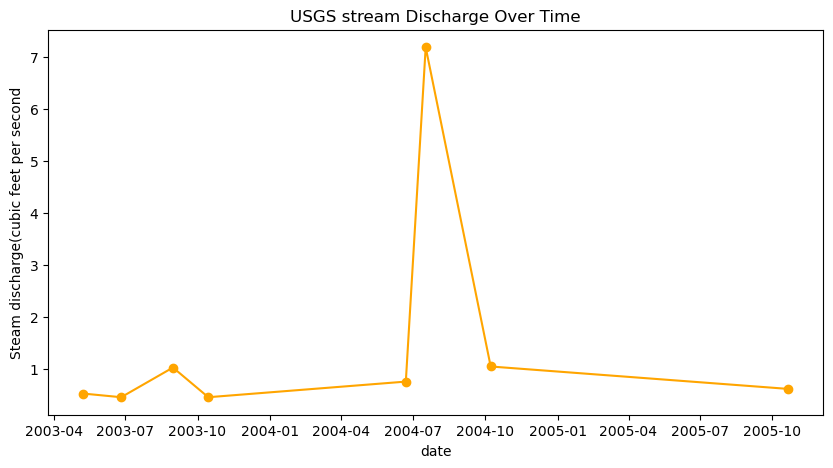

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(df["time"], df["value"], marker="o", color ="orange")
plt.title ("USGS stream Discharge Over Time")
plt.xlabel("date")
plt.ylabel("Steam discharge(cubic feet per second")
plt.figure


In [19]:
plt.show()